In [1]:
# import neccesary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the data 
df = pd.read_csv('../data/raw/fraud_data.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Filter data 
df_filter = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

In [5]:
# remove columns that are not needed
df_model = df_filter.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [6]:
df_model.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
2,1,TRANSFER,181.00,181.0,0.0,0.0,0.00,1
3,1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1
15,1,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0
19,1,TRANSFER,215310.30,705.0,0.0,22425.0,0.00,0
24,1,TRANSFER,311685.89,10835.0,0.0,6267.0,2719172.89,0


In [7]:
# Convert the "step" column to "hourOfDay" by taking the modulus with 24
df_model["hourOfDay"] = df_model["step"] % 24

In [8]:
df_model = df_model.drop(["step"], axis=1)

C:\Users\Jonathan\AppData\Local\Temp\ipykernel_21904\1379046997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = fraud_rate_by_hour.index, y = fraud_rate_by_hour.values, edgecolor = 'black', linewidth = 0.5, palette = "viridis")


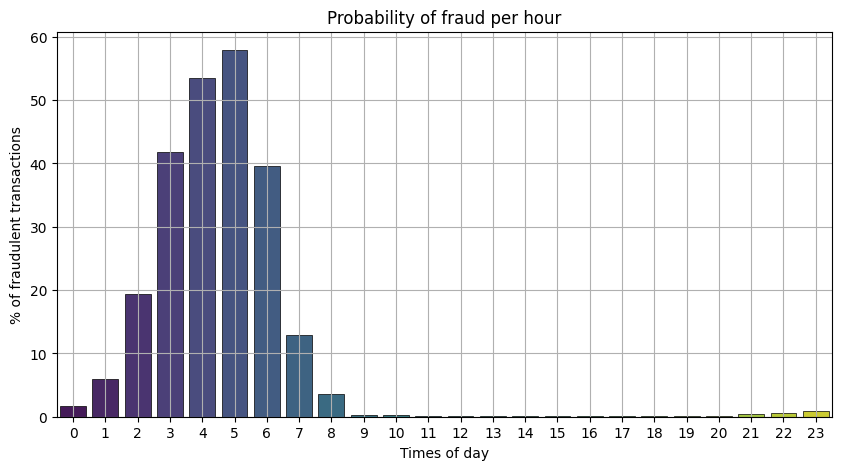

In [9]:
# Plot of Probability of fraud per hour
plt.figure(figsize=(10,5))
fraud_rate_by_hour = df_model.groupby("hourOfDay")["isFraud"].mean() * 100
sns.barplot(x = fraud_rate_by_hour.index, y = fraud_rate_by_hour.values, edgecolor = 'black', linewidth = 0.5, palette = "viridis")
plt.xticks(range(24))
plt.title("Probability of fraud per hour")
plt.xlabel("Times of day")
plt.ylabel("% of fraudulent transactions")
plt.grid(True)
plt.show()

In [10]:
df_model["errorBalanceOrig"] = df_model["newbalanceOrig"] + df_model["amount"] - df_model["oldbalanceOrg"]
df_model["errorBalanceDest"] =  df_model["oldbalanceDest"] + df_model["amount"] - df_model["newbalanceDest"]
df_model["fractionAmount"] = df_model["amount"] / (df_model["oldbalanceOrg"] + 1)

In [11]:
df_model['type'] = df_model['type'].map({'TRANSFER': 1, 'CASH_OUT': 0})

In [12]:
df_model[["isFraud", "errorBalanceOrig", "errorBalanceDest", "type", "amount", "fractionAmount"]].head(50)

,isFraud,errorBalanceOrig,errorBalanceDest,type,amount,fractionAmount
2,1,0.000000e+00,181.00,1,181.00,9.945055e-01
3,1,0.000000e+00,21363.00,0,181.00,9.945055e-01
15,0,2.138089e+05,182703.50,0,229133.94,1.495067e+01
19,0,2.146053e+05,237735.30,1,215310.30,3.049721e+02
24,0,3.008509e+05,-2401220.00,1,311685.89,2.876392e+01
42,0,8.356930e+04,396799.55,0,110414.71,4.112830e+00
47,0,5.501188e+04,63100.72,0,56953.90,2.931205e+01
48,0,5.346890e+03,-5795447.02,0,5346.89,5.346890e+03
51,0,2.849770e+03,49003.30,0,23261.30,1.139560e+00
58,0,0.000000e+00,54744.51,1,62610.80,7.913897e-01


In [13]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770409 entries, 2 to 6362619
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   type              int64  
 1   amount            float64
 2   oldbalanceOrg     float64
 3   newbalanceOrig    float64
 4   oldbalanceDest    float64
 5   newbalanceDest    float64
 6   isFraud           int64  
 7   hourOfDay         int64  
 8   errorBalanceOrig  float64
 9   errorBalanceDest  float64
 10  fractionAmount    float64
dtypes: float64(8), int64(3)
memory usage: 253.6 MB


In [14]:
df_model = df_model.astype('float64')
df_model.to_parquet('sentinel_cleaned_data.parquet', index =  False)